## 1. Prétraitement des données: Charger et vectoriser le jeu de données IMDB

In [98]:
import keras
import numpy as np

# Charger le jeu de données IMDB
num_words = 10000  # garder les 10k mots les plus fréquents
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

print(f"Données d'entraînement: {len(train_data)} critiques")
print(f"Données de test: {len(test_data)} critiques")

# Afficher un exemple de critique et son label
print(f"\nExemple de critique d'entraînement (encodée):\n{train_data[0]}\n")
print(f"Label correspondant: {train_labels[0]}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Données d'entraînement: 25000 critiques
Données de test: 25000 critiques

Exemple de critique d'entraînement (encodée):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224,

### Vectorisation des séquences d'entiers en matrices binaires (one-hot encoding)

In [99]:
def vectorize_sequences(sequences, dimension=10000):
    # Crée une matrice de zéros de forme (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # Définit les indices spécifiques de results[i] à 1
    return results

# Vectoriser les données d'entraînement et de test
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Vectoriser les labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print(f"\nShape des données d'entraînement vectorisées: {x_train.shape}")
print(f"Exemple de critique vectorisée (premiers 50 éléments):\n{x_train[0][:50]}")


Shape des données d'entraînement vectorisées: (25000, 10000)
Exemple de critique vectorisée (premiers 50 éléments):
[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 1. 0.]


### Division des données en ensembles d'entraînement, de validation et de test

In [100]:
# Créer un ensemble de validation à partir des données d'entraînement
x_val = x_train[:10000]
y_val = y_train[:10000]

x_partial_train = x_train[10000:]
y_partial_train = y_train[10000:]

print(f"\nShape des données d'entraînement partielles: {x_partial_train.shape}")
print(f"Shape des labels d'entraînement partiels: {y_partial_train.shape}")
print(f"Shape des données de validation: {x_val.shape}")
print(f"Shape des labels de validation: {y_val.shape}")
print(f"Shape des données de test: {x_test.shape}")
print(f"Shape des labels de test: {y_test.shape}")


Shape des données d'entraînement partielles: (15000, 10000)
Shape des labels d'entraînement partiels: (15000,)
Shape des données de validation: (10000, 10000)
Shape des labels de validation: (10000,)
Shape des données de test: (25000, 10000)
Shape des labels de test: (25000,)


## 2. Construire le modèle :

In [101]:
from keras import models
from keras import layers

# Construire le modèle
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Compiler le modèle
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraîner le modèle :

Nous allons maintenant entraîner le modèle sur les données d'entraînement partielles et évaluer ses performances sur les données de validation. La méthode `fit` de Keras se charge de l'entraînement.

In [102]:
history = model.fit(x_partial_train,
                    y_partial_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

print("\nEntraînement du modèle terminé.")

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - accuracy: 0.7695 - loss: 0.5406 - val_accuracy: 0.8606 - val_loss: 0.4065
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8909 - loss: 0.3315 - val_accuracy: 0.8806 - val_loss: 0.3202
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9189 - loss: 0.2449 - val_accuracy: 0.8877 - val_loss: 0.2875
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9308 - loss: 0.1983 - val_accuracy: 0.8863 - val_loss: 0.2789
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9441 - loss: 0.1658 - val_accuracy: 0.8872 - val_loss: 0.2794
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9553 - loss: 0.1394 - val_accuracy: 0.8867 - val_loss: 0.2856
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9613 - loss: 0.1231 - val_accuracy: 0.8857 - val_loss: 0.2970
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9689 - loss: 0.1030 - val_accuracy: 0.8836 -

## 4. Évaluer le modèle :

### 4.1. Visualisation de la perte et de la précision d'entraînement et de validation

Nous allons utiliser l'objet `history` retourné par la méthode `fit` pour tracer l'évolution de la perte et de la précision sur les ensembles d'entraînement et de validation.

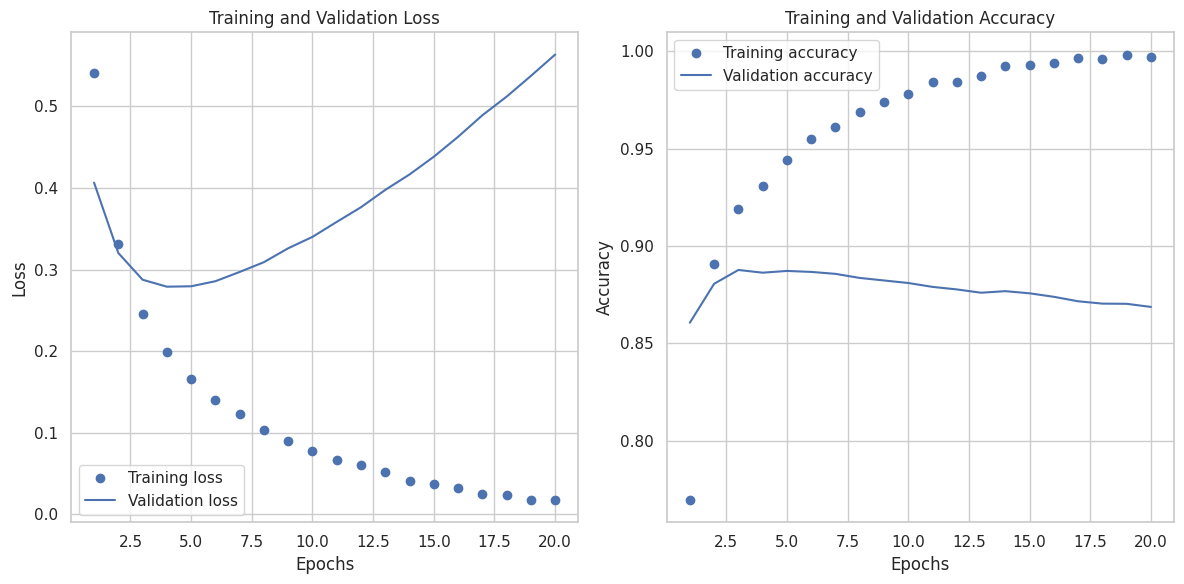

In [103]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 6))

# Plot de la perte
plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, 1er graphique
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot de la précision
plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, 2ème graphique
plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 4.2. Ré-entraînement du modèle avec un nombre optimal d'époques

D'après les graphiques ci-dessus, nous pouvons observer que le modèle commence à surapprendre (overfit) après quelques époques, la perte de validation augmentant et la précision de validation diminuant tandis que la perte d'entraînement continue de baisser. Pour éviter le surapprentissage, nous allons ré-entraîner un nouveau modèle avec un nombre d'époques plus faible (par exemple, 4 ou 5 époques, où la perte de validation était à son minimum).

Nous recréons le modèle pour nous assurer qu'il est réinitialisé et n'a pas appris des époques précédentes.

In [104]:
from keras import models
from keras import layers

# Reconstruire le modèle (pour avoir des poids frais)
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Recompiler le modèle
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Ré-entraîner le modèle avec un nombre optimal d'époques
# Nous choisissons 4 époques comme exemple où la validation loss est proche de son minimum
history_optimal = model.fit(x_partial_train,
                            y_partial_train,
                            epochs=4, # Optimal number of epochs
                            batch_size=512,
                            validation_data=(x_val, y_val))

print("\nRé-entraînement du modèle avec un nombre optimal d'époques terminé.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.7643 - loss: 0.5428 - val_accuracy: 0.8611 - val_loss: 0.4042
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8912 - loss: 0.3289 - val_accuracy: 0.8826 - val_loss: 0.3133
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9183 - loss: 0.2412 - val_accuracy: 0.8887 - val_loss: 0.2849
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9359 - loss: 0.1933 - val_accuracy: 0.8870 - val_loss: 0.2803

Ré-entraînement du modèle avec un nombre optimal d'époques terminé.


### 4.3. Évaluation du modèle final sur l'ensemble de test

Après avoir ré-entraîné le modèle avec un nombre optimal d'époques pour éviter le surapprentissage, nous évaluons ses performances sur l'ensemble de test (`x_test`, `y_test`).

In [105]:
results = model.evaluate(x_test, y_test)
print(f"\nRésultats de l'évaluation sur l'ensemble de test :\nLoss: {results[0]:.4f}, Accuracy: {results[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8795 - loss: 0.2952

Résultats de l'évaluation sur l'ensemble de test :
Loss: 0.2952, Accuracy: 0.8795


 5. ANALYSER LES RÉSULTATS


In [108]:
# 5. ANALYSER LES RÉSULTATS

print("\n=== 5. Analyse finale des résultats ===")
# Utiliser les valeurs de précision d'entraînement et de validation des 20 premières époques
print(f"Précision d'entraînement maximale obtenue (20 époques) : {max(acc_values)*100:.2f}%")
print(f"Précision de validation maximale obtenue (20 époques) : {max(val_acc_values)*100:.2f}%")
print("-" * 50)
# Utiliser les résultats de l'évaluation finale sur l'ensemble de test
print(f"Perte finale sur l'ensemble de TEST : {results[0]:.4f}")
print(f"Précision finale sur l'ensemble de TEST : {results[1]*100:.2f}%")
print("-" * 50)


=== 5. Analyse finale des résultats ===
Précision d'entraînement maximale obtenue (20 époques) : 99.84%
Précision de validation maximale obtenue (20 époques) : 88.77%
--------------------------------------------------
Perte finale sur l'ensemble de TEST : 0.2952
Précision finale sur l'ensemble de TEST : 87.95%
--------------------------------------------------


## Conclusion
Dans ce mini-projet, vous avez conçu et entraîné un modèle de classification binaire de texte à l'aide du jeu de données IMDB. Vous avez appris à prétraiter des données textuelles, à concevoir un réseau de neurones et à évaluer ses performances grâce à des ensembles de validation et de test. La visualisation des métriques d'entraînement et de validation vous a également permis de comprendre l'importance d'éviter le surapprentissage. Ce projet constitue une base solide pour des tâches de traitement automatique du langage naturel plus avancées, telles que l'analyse des sentiments, la génération de texte et la modélisation de séquences.